In [28]:
! pip install mlxtend

INFO: pip is looking at multiple versions of mlxtend to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 2.8 MB/s eta 0:00:01
   ------------------------------- -------- 1.0/1.4 MB 1.9 MB/s eta 0:00:01
   -------------------------------------- - 1.3/1.4 MB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 1.3 MB/s  0:00:01


In [29]:
import pandas as pd #for reading the data
from sklearn.preprocessing import MinMaxScaler #for data standardization
from sklearn.model_selection import train_test_split #to split the data into train and test parts
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder #to encode the data to numerical
from sklearn import svm, datasets
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report, cohen_kappa_score, matthews_corrcoef, log_loss, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV #for cross validation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# A function that would plot for us the decision regions of a problem
from mlxtend.plotting import plot_decision_regions

# This library will be used to measure the difference in times between the start and the end of a process
import time
import numpy as np


## Data Preprocessing

#### Load the data in pandas data frame

In [30]:
data = pd.read_csv('social data.csv')
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0


#### Explore the data 

In [31]:
df = data.copy()
df['Purchased'].value_counts()


Purchased
0    257
1    143
Name: count, dtype: int64

In [32]:
df.dtypes


User ID              int64
Gender              object
Age                float64
EstimatedSalary    float64
Purchased            int64
dtype: object

In [33]:
df = df.drop(['User ID'], axis=1)
df.head()


,Gender,Age,EstimatedSalary,Purchased
0,Male,19.0,19000.0,0
1,Male,35.0,20000.0,0
2,Female,26.0,43000.0,0
3,Female,27.0,57000.0,0
4,Male,19.0,76000.0,0


In [34]:
label = LabelEncoder()
df['Gender'] = label.fit_transform(df['Gender'])

df['Age'] = df['Age'].astype(float)
df['EstimatedSalary'] = df['EstimatedSalary'].astype(float)
df['Purchased'] = df['Purchased'].astype(int)


In [35]:
df.dtypes


Gender               int64
Age                float64
EstimatedSalary    float64
Purchased            int64
dtype: object

In [36]:
df.isna().sum()


Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

### Split the data into targets and inputs

In [ ]:
inputs= df[['Gender', 'Age', 'EstimatedSalary']]
target = df['Purchased']


### Split the data into train and test sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    inputs, target, test_size=0.3, random_state=42, stratify=target
)


In [39]:
pd.DataFrame({
    'train': y_train.value_counts(normalize=True),
    'test': y_test.value_counts(normalize=True)
})


,train,test
Purchased,,
0,0.642857,0.641667
1,0.357143,0.358333


In [40]:
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_rescaled = scaler.fit_transform(X_train)
X_test_rescaled = scaler.transform(X_test)


### Classification with a linear SVM

In [41]:
tuned_parameters = [
    {'kernel': ['linear'], 'C': 10},
    {'kernel': ['poly'], 'C': 10},
    {'kernel': ['rbf'], 'C': 10},
]


In [42]:
linear_svm = svm.SVC(kernel='linear', C=10)
linear_svm.fit(X_train_rescaled, y_train)


,C,10
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [43]:
y_pred = linear_svm.predict(X_test_rescaled)


### Analyze the results of the SVM

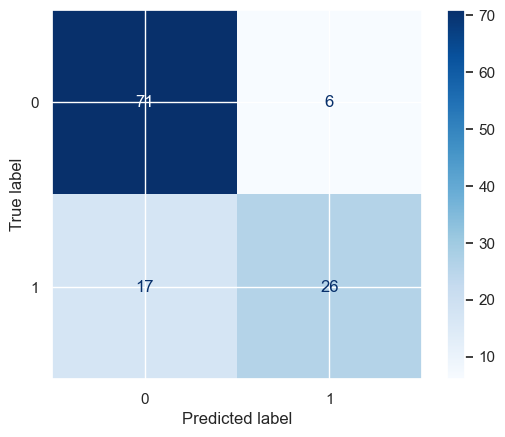

In [44]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=linear_svm.classes_)
disp.plot(cmap='Blues')
plt.show()


In [45]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.81      0.92      0.86        77
           1       0.81      0.60      0.69        43

    accuracy                           0.81       120
   macro avg       0.81      0.76      0.78       120
weighted avg       0.81      0.81      0.80       120



## Ploting decision boundaries

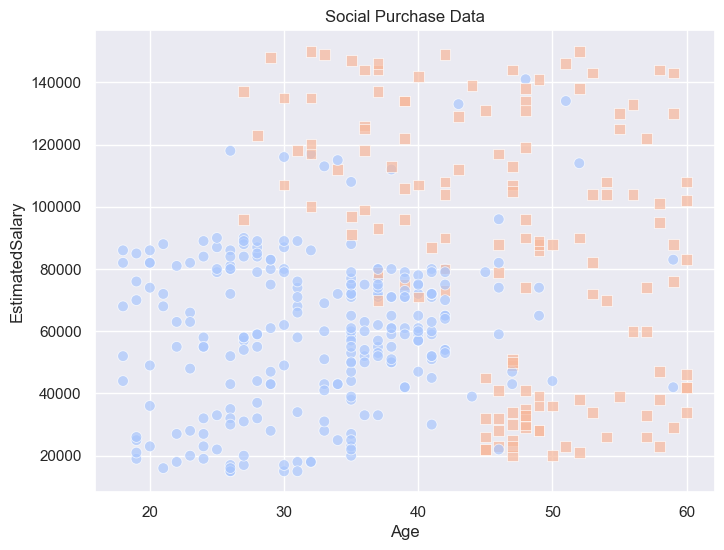

In [46]:
# Use only Age and EstimatedSalary for 2D plotting
X_plot = df[['Age', 'EstimatedSalary']]
y_plot = df['Purchased']

scaler_plot = MinMaxScaler(feature_range=(-1, 1))
X_plot_scaled = scaler_plot.fit_transform(X_plot)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Age',
    y='EstimatedSalary',
    hue='Purchased',
    palette='coolwarm',
    style='Purchased',
    markers={0: 'o', 1: 's'},
    s=60,
    alpha=0.7,
    legend=False
)

plt.title('Social Purchase Data')
plt.show()


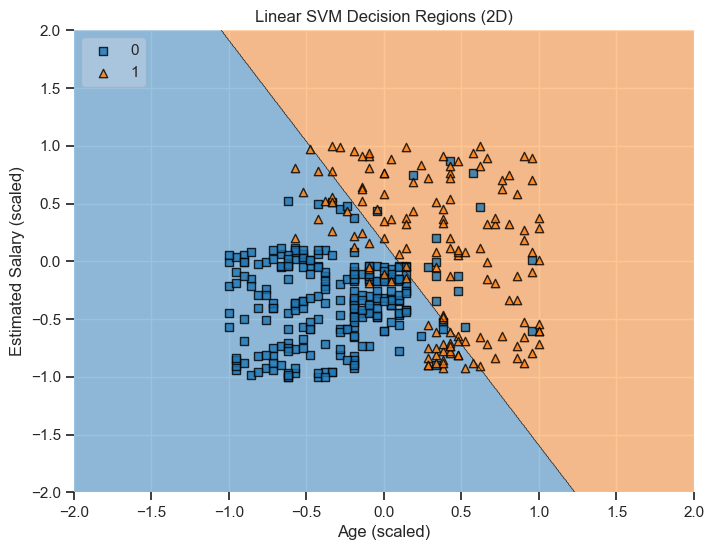

In [47]:
linear_svm_plot = svm.SVC(kernel='linear', C=10)
linear_svm_plot.fit(X_plot_scaled, y_plot)

plt.figure(figsize=(8, 6))
plot_decision_regions(X_plot_scaled, y_plot.to_numpy(), clf=linear_svm_plot, legend=2)
plt.xlabel('Age (scaled)')
plt.ylabel('Estimated Salary (scaled)')
plt.title('Linear SVM Decision Regions (2D)')
plt.show()


### Polynomial kernel

In [48]:
poly_svm_plot = svm.SVC(kernel='poly', degree=3, C=10, gamma='scale')
poly_svm_plot.fit(X_plot_scaled, y_plot)


,C,10
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


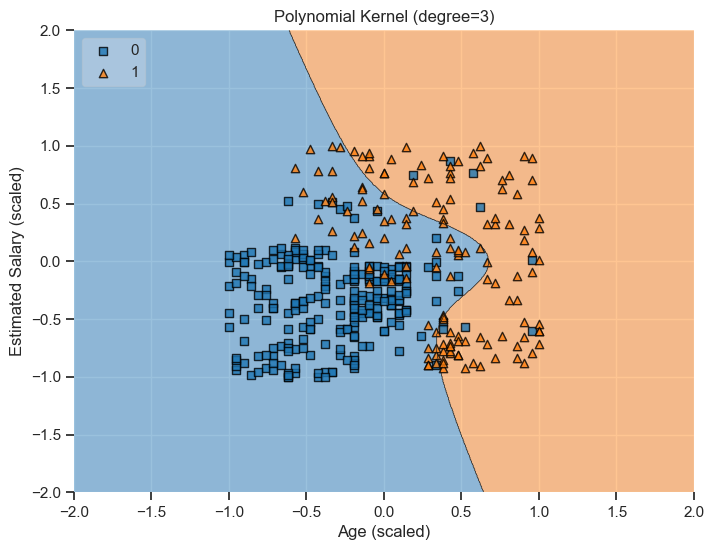

In [49]:
plt.figure(figsize=(8, 6))
plot_decision_regions(X_plot_scaled, y_plot.to_numpy(), clf=poly_svm_plot, legend=2)
plt.xlabel('Age (scaled)')
plt.ylabel('Estimated Salary (scaled)')
plt.title('Polynomial Kernel (degree=3)')
plt.show()


### Sigmoid kernel

In [50]:
sigmoid_svm_plot = svm.SVC(kernel='sigmoid', C=10, gamma='scale')
sigmoid_svm_plot.fit(X_plot_scaled, y_plot)


,C,10
,kernel,'sigmoid'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


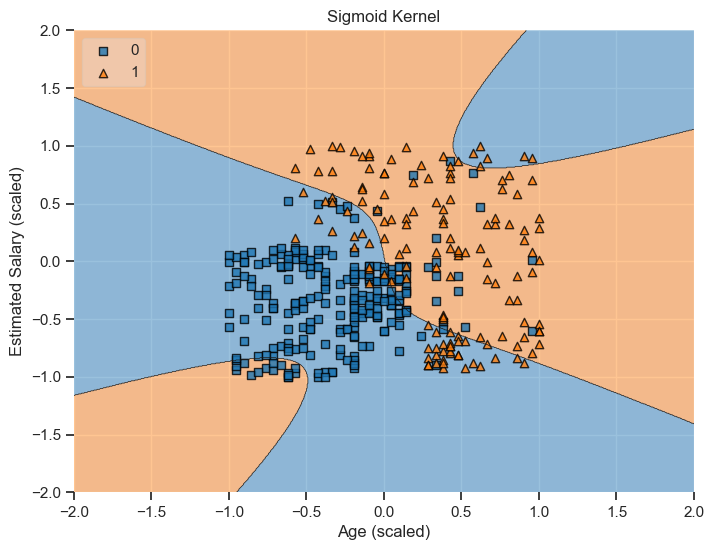

In [51]:
plt.figure(figsize=(8, 6))
plot_decision_regions(X_plot_scaled, y_plot.to_numpy(), clf=sigmoid_svm_plot, legend=2)
plt.xlabel('Age (scaled)')
plt.ylabel('Estimated Salary (scaled)')
plt.title('Sigmoid Kernel')
plt.show()


### Radial kernel

In [52]:
rbf_svm_plot = svm.SVC(kernel='rbf', C=10, gamma='scale')
rbf_svm_plot.fit(X_plot_scaled, y_plot)


,C,10
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


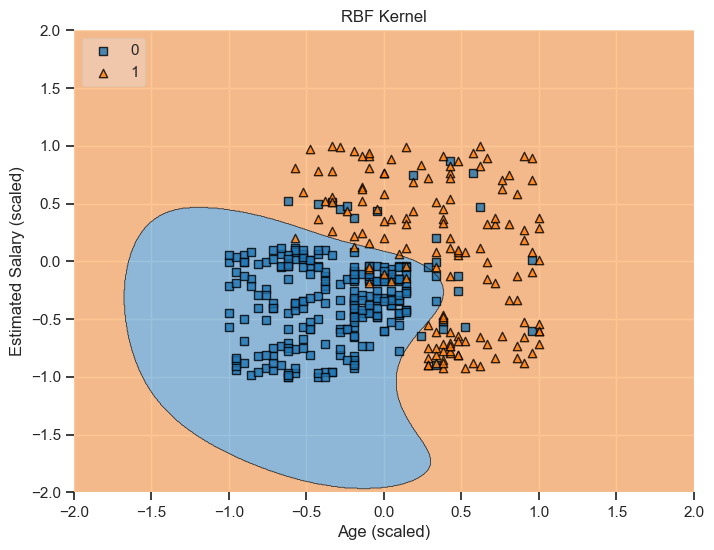

In [53]:
plt.figure(figsize=(8, 6))
plot_decision_regions(X_plot_scaled, y_plot.to_numpy(), clf=rbf_svm_plot, legend=2)
plt.xlabel('Age (scaled)')
plt.ylabel('Estimated Salary (scaled)')
plt.title('RBF Kernel')
plt.show()
